# Evaluate MOFA-Flex models

In [19]:
sys.path.append("docs/source/unfinished_temp_notebooks/MOFA_Flex/")

from helper_functions import evaluate_mofaflex
from helper_functions import spatial_statistics_summary_plot
from helper_functions import model_performance_summary_plot

import mofaflex as mfl
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/lrdata")
lrdata = sc.read(merfish_path / "WB_MERFISH_animal2_coronal_lrdata.h5ad")

In [ ]:
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_Normal.hdf5")
eval_path = Path(models_path / "evaluation_results_Normal")
results_normal = evaluate_mofaflex(
    model,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [ ]:
model_GP_SnS = mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_GP_SnS.hdf5")
eval_path = Path(models_path / "evaluation_results_GP_SnS")
results_GP_SnS = evaluate_mofaflex(
    model_GP_SnS,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [ ]:
model_nonneg = mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_nonneg.hdf5")
eval_path = Path(models_path / "evaluation_results_nonneg")
results_nonneg = evaluate_mofaflex(
    model_nonneg,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [22]:
model_sns_sns = mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_SnS_SnS.hdf5")
eval_path = Path(models_path / "evaluation_results_SnS_SnS")
results_sns_sns = evaluate_mofaflex(
    model_sns_sns,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


In [23]:
model_sns_normal_weight = mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_SnS_normal_weight.hdf5")
eval_path = Path(models_path / "evaluation_results_SnS_normal_weight")
results_sns_normal_weight = evaluate_mofaflex(
    model_sns_normal_weight,
    lrdata,
    eval_path,
    group="group_1",
    n_clusters=None,
    obs_keys=("cell_type", "major_brain_region"),
    classification_key="major_brain_region",
    spatial_key="X_spatial_coords",
    random_state=42)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


# Summary plots

In [24]:
models = {
    "Normal_Priors": results_normal,
    "Non_Negativity": results_nonneg,
    "GP_SnS": results_GP_SnS,
    "SnS_SnS": results_sns_sns,
    "SnS_Normal_Weight": results_sns_normal_weight
}

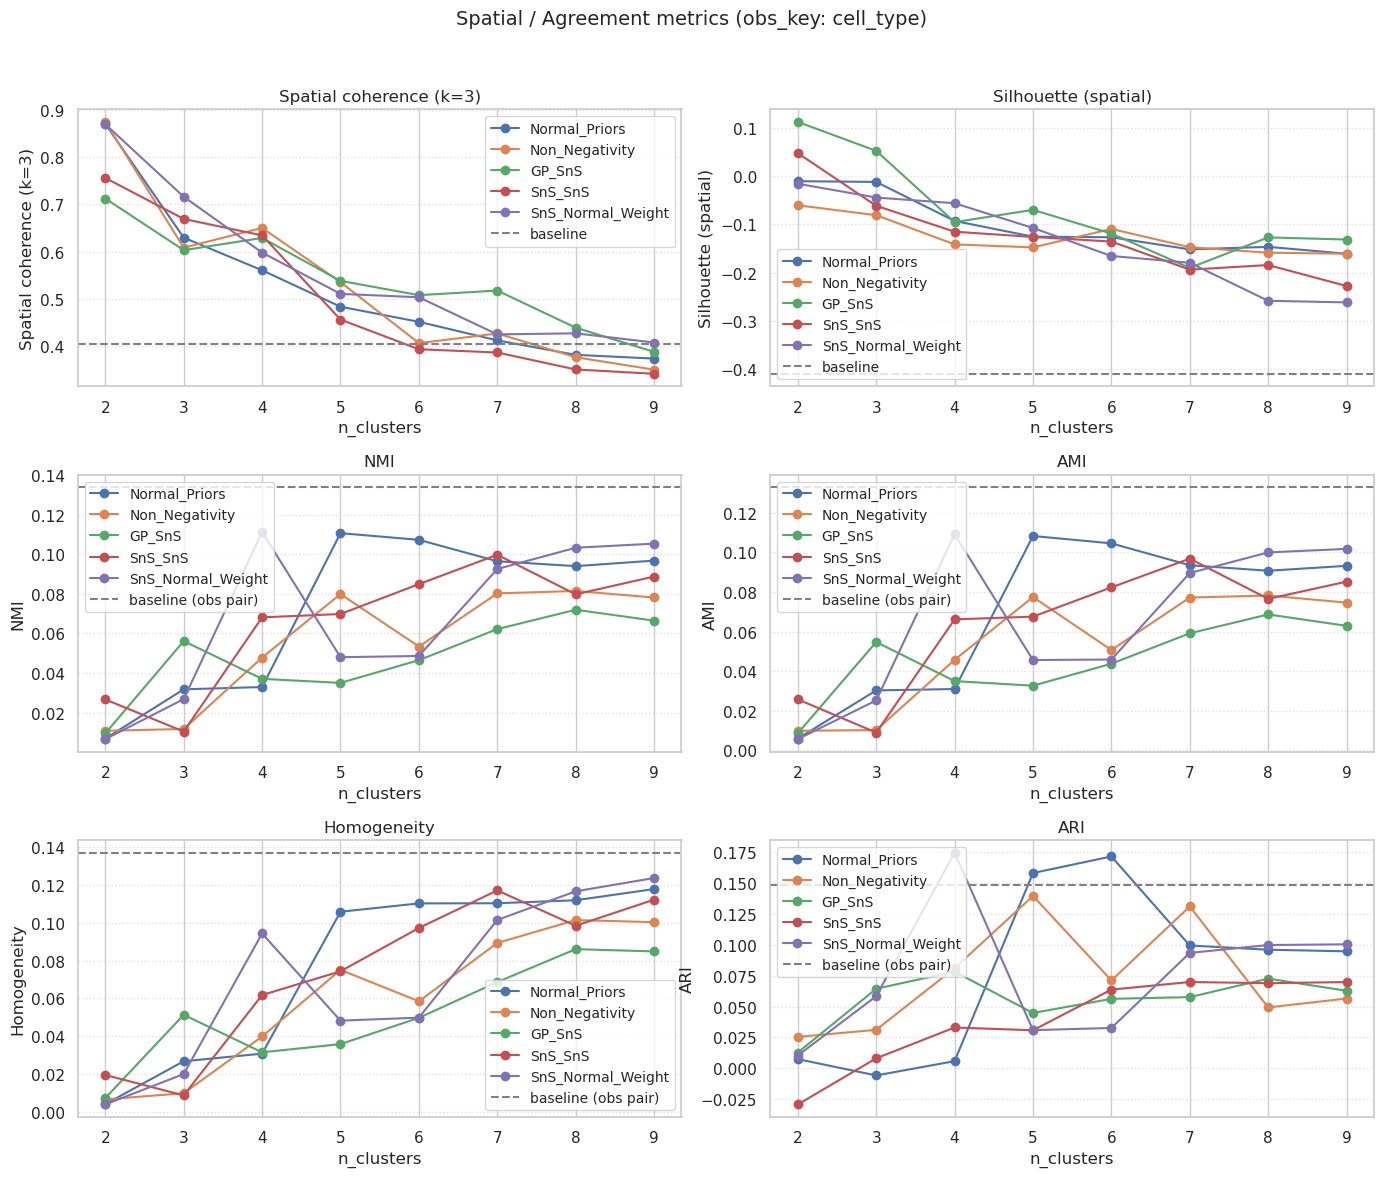

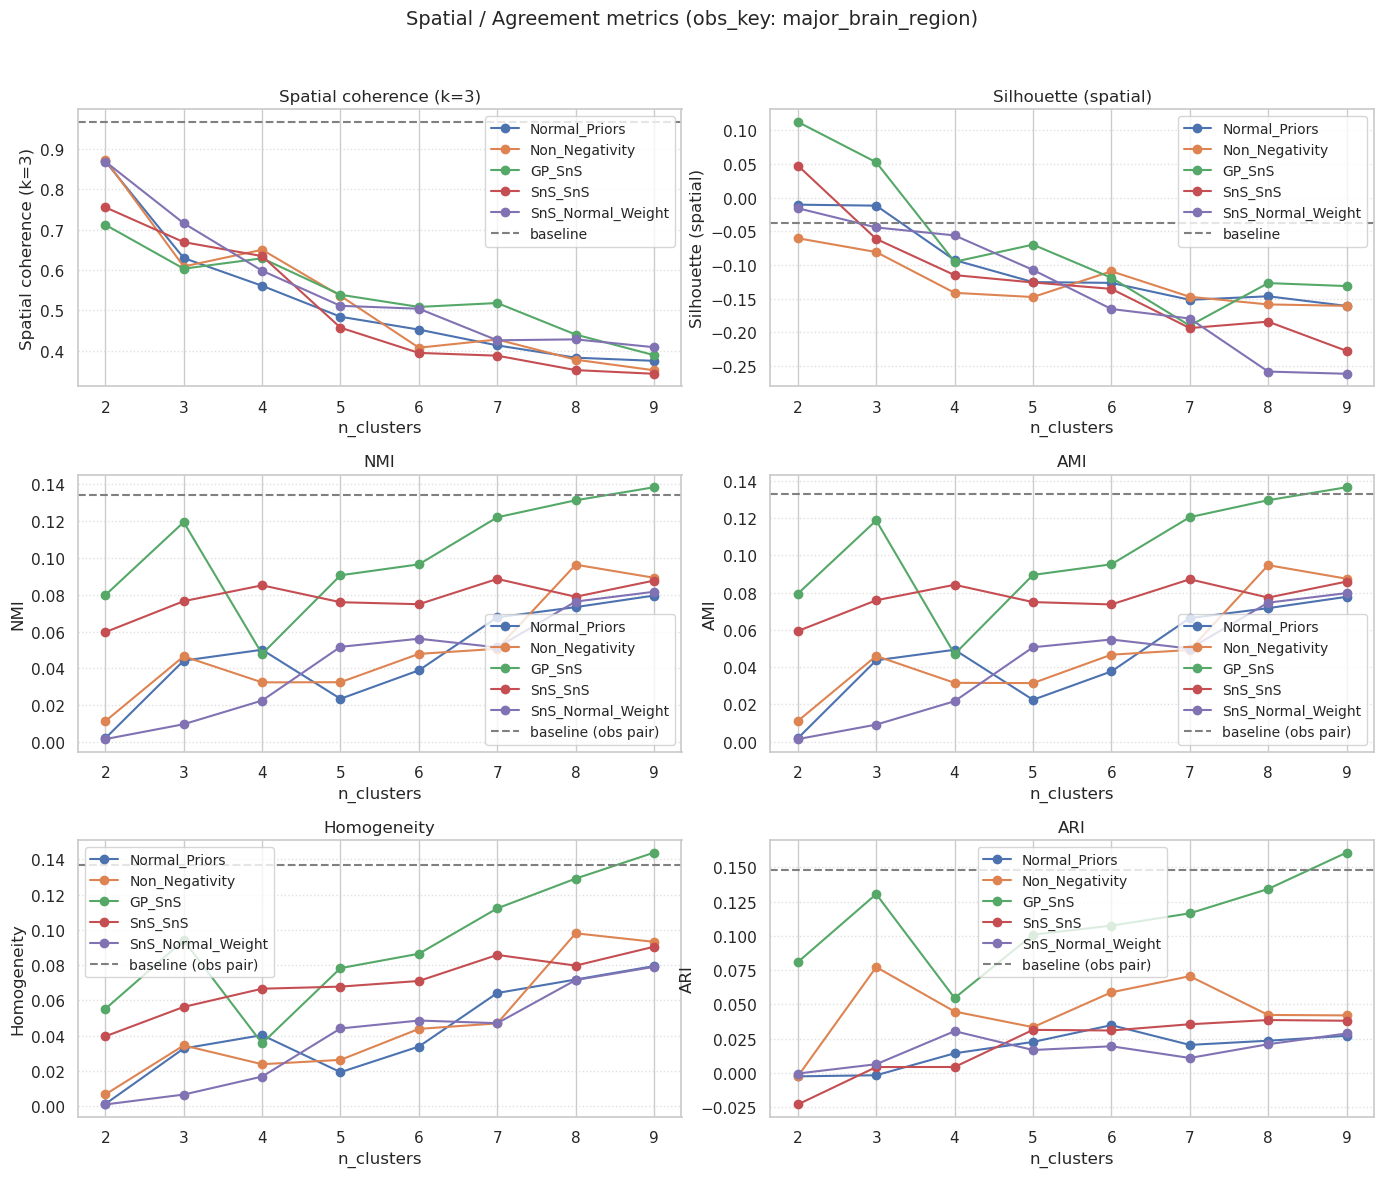

In [25]:
spatial_statistics_summary_plot(models, obs_keys=("cell_type", "major_brain_region"))

(                    mean_r2  accuracy  auc_weighted
 model                                              
 Normal_Priors      0.713457    0.3401      0.737527
 Non_Negativity     0.707430    0.3082      0.729942
 GP_SnS             0.727423    0.4173      0.797266
 SnS_SnS            0.706137    0.2858      0.707097
 SnS_Normal_Weight  0.683787    0.3250      0.715568,
 <Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Model performance summary'}, ylabel='Value'>)

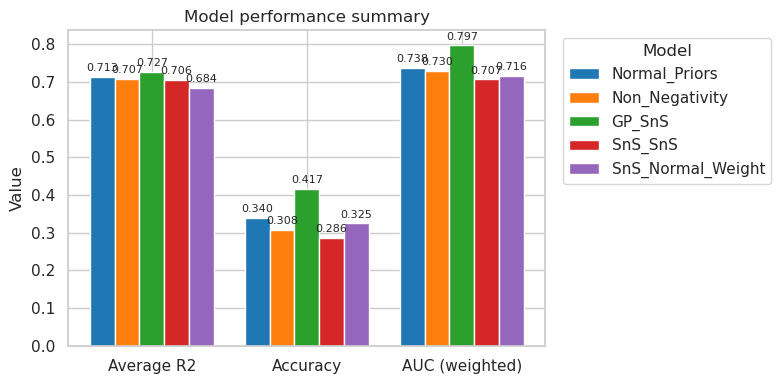

In [26]:
model_performance_summary_plot(models)